# LAB | Hyperparameter Tuning

**Load the data**

Finally step in order to maximize the performance on your Spaceship Titanic model.

The data can be found here:

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv

Metadata

https://github.com/data-bootcamp-v4/data/blob/main/spaceship_titanic.md

So far we've been training and evaluating models with default values for hyperparameters.

Today we will perform the same feature engineering as before, and then compare the best working models you got so far, but now fine tuning it's hyperparameters.

In [1]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
spaceship = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv")
spaceship.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


Now perform the same as before:
- Feature Scaling
- Feature Selection


In [3]:
def df_info(df):
    print("\n    ---- df info ---")
    print(df.info())
    print("\n    ---- Empty Values ---")
    print(df.isna().sum())
    print("\n    ----- Dtypes -----")
    print(df.dtypes)
    print("\n    ---- Statistics ---")
    return df.describe()
df_info(spaceship)


    ---- df info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None

    ---- Empty Values ---
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destinat

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [4]:
X=spaceship

In [5]:
X.rename(columns={col : col.strip() for col in X.columns}, inplace = True)
X.rename(columns={col : col.replace(" ", "_").lower() for col in X.columns}, inplace = True)
X ["cabin"] = X ["cabin"].str[0]
X = X.dropna()
X.head()

,passengerid,homeplanet,cryosleep,cabin,destination,age,vip,roomservice,foodcourt,shoppingmall,spa,vrdeck,name,transported
0,0001_01,Europa,False,B,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [6]:
target = X["transported"]
features = X.drop(columns = ["passengerid","name", "transported"])
features = pd.get_dummies (features, drop_first = True)

- Now let's use the best model we got so far in order to see how it can improve when we fine tune it's hyperparameters.

In [7]:
from sklearn.preprocessing import MinMaxScaler


X_train,X_test, y_train,y_test = train_test_split(features,target,test_size=0.2,random_state=0)
X_train.head(5)

scaler = MinMaxScaler()

X_train_norm = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

X_test_norm = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
display(X_train_norm.head(5))
display(X_test_norm.head(5))

,age,roomservice,foodcourt,shoppingmall,spa,vrdeck,homeplanet_Europa,homeplanet_Mars,cryosleep_True,cabin_B,cabin_C,cabin_D,cabin_E,cabin_F,cabin_G,cabin_T,destination_PSO J318.5-22,destination_TRAPPIST-1e,vip_True
0,0.405063,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.050633,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.379747,0.00000,0.007916,0.000000,0.051276,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.215190,0.00131,0.000000,0.046111,0.016378,0.000049,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.329114,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


,age,roomservice,foodcourt,shoppingmall,spa,vrdeck,homeplanet_Europa,homeplanet_Mars,cryosleep_True,cabin_B,cabin_C,cabin_D,cabin_E,cabin_F,cabin_G,cabin_T,destination_PSO J318.5-22,destination_TRAPPIST-1e,vip_True
0,0.632911,0.0,0.000000,0.0,0.00000,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.227848,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,0.189873,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.658228,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.784810,0.0,0.054775,0.0,0.07774,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

forest = RandomForestClassifier()
forest.fit(X_train_norm, y_train)
pred = forest.predict(X_test_norm)

#print("MAE", mean_absolute_error(pred, y_test))
#print("RMSE", np.sqrt(mean_squared_error(pred, y_test)))
print("Accuracy", forest.score(X_test_norm, y_test))
print("F1 score", f1_score(y_test, pred))
print("Precision", precision_score(y_test, pred))
print("Recall", recall_score(y_test, pred))

Accuracy 0.789712556732224
F1 score 0.7884322678843226
Precision 0.7932618683001531
Recall 0.783661119515885


In [9]:
RandomForestClassifier()

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


- Evaluate your model

In [10]:
# Bootstrapping 

In [11]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
model.fit(X_train, y_train)

print(f"OOB Score: {model.oob_score_}")

OOB Score: 0.7886071158213475


**Grid/Random Search**

For this lab we will use Grid Search.

- Define hyperparameters to fine tune.

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [13]:
param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [None, 10, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"] 
}

- Run Grid Search

In [14]:
rf_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train_norm, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


- Evaluate your model

In [15]:
print("Accuracy", forest.score(X_test_norm, y_test))
print("F1 score", f1_score(y_test, pred))
print("Precision", precision_score(y_test, pred))
print("Recall", recall_score(y_test, pred))

Accuracy 0.789712556732224
F1 score 0.7884322678843226
Precision 0.7932618683001531
Recall 0.783661119515885


--- Classification ---
              precision    recall  f1-score   support

       False       0.70      0.79      0.75       661
        True       0.76      0.67      0.71       661

    accuracy                           0.73      1322
   macro avg       0.73      0.73      0.73      1322
weighted avg       0.73      0.73      0.73      1322

--- Confussion Matrix ---


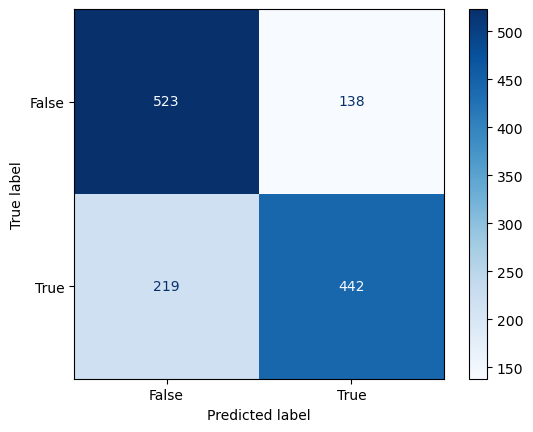

In [16]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)

print("--- Classification ---")
print(classification_report(y_test, y_pred))

print("--- Confussion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot(cmap="Blues")
plt.show()

In [17]:
print(f"Best hiperparameters: {grid_search.best_params_}")
print(f"Best score of cross validation: {grid_search.best_score_:.4f}")

Best hiperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 500}
Best score of cross validation: 0.8075
